# Posture Detection V2 — 03 MotionBERT 3D Pose Lifting

This notebook converts Notebook 02's temporal H36M-17 2D keypoint windows into 3D pose sequences using the official MotionBERT-Lite 3D-pose checkpoint. It preserves window identities, merges overlapping predictions back into video timelines, visualizes 2D/3D poses, and records inference latency.

**Important:** the public Pexels clip is a pipeline smoke test, not training or evaluation data. MotionBERT depth is learned monocular depth—not metric depth from a calibrated camera.

## 1. Environment

The official source and checkpoint are downloaded once from the authors' Hugging Face repository. Git is not required. Run the next cell once, then **restart the kernel** before continuing; PyTorch 2.2 requires NumPy 1.x in this environment.

In [1]:
# Run once, then restart the kernel before running the remaining cells.
%pip install -q "numpy<2" easydict pyyaml huggingface_hub tqdm pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ultralytics 8.3.113 requires opencv-python>=4.6.0, which is not installed.
opencv-contrib-python 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
streamlit 1.40.1 requires packaging<25,>=20, but you have packaging 26.3 which is incompatible.
streamlit 1.40.1 requires pandas<3,>=1.4.0, but you have pandas 3.0.6 which is incompatible.
streamlit 1.40.1 requires pillow<12,>=7.1.0, but you have pillow 12.3.0 which is incompatible.
streamlit 1.40.1 requires protobuf<6,>=3.20, but you have protobuf 7.36.2 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pyth

### Restart checkpoint

After the installation cell finishes, restart the Jupyter kernel. Begin again from the import cell below; you do not need to rerun the installation cell.

In [1]:
import json
import platform
import sys
import time
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
if int(np.__version__.split('.')[0]) >= 2:
    raise RuntimeError('NumPy 2.x is incompatible with the installed PyTorch 2.2 build. Restart the kernel after running this cell.')
import torch
from tqdm.auto import tqdm

print('Python:', platform.python_version())
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

Python: 3.12.5
PyTorch: 2.2.2+cpu
CUDA available: False


c:\Users\manth\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Locate the V2 project and Notebook 02 outputs

In [2]:
working_directory = Path.cwd()
if working_directory.name == 'notebooks':
    PROJECT_ROOT = working_directory.parent
elif working_directory.name == 'project_v2':
    PROJECT_ROOT = working_directory
else:
    PROJECT_ROOT = working_directory / 'project_v2'

KEYPOINT_DIR = PROJECT_ROOT / 'data' / 'keypoints_2d'
POSE3D_DIR = PROJECT_ROOT / 'data' / 'poses_3d'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'motionbert_3d'
MOTIONBERT_ROOT = PROJECT_ROOT / 'motionbert' / 'MotionBERT'
WINDOW_LENGTH = 81
WINDOW_FILE = KEYPOINT_DIR / f'motionbert_windows_{WINDOW_LENGTH}.npz'
WINDOW_MANIFEST_FILE = KEYPOINT_DIR / f'motionbert_windows_{WINDOW_LENGTH}_manifest.csv'
SEQUENCE_AUDIT_FILE = PROJECT_ROOT / 'results' / 'temporal_keypoints' / 'sequence_extraction_audit.csv'
for directory in (POSE3D_DIR, RESULTS_DIR, MOTIONBERT_ROOT.parent):
    directory.mkdir(parents=True, exist_ok=True)
for required in (WINDOW_FILE, WINDOW_MANIFEST_FILE, SEQUENCE_AUDIT_FILE):
    if not required.exists():
        raise FileNotFoundError(f'Missing Notebook 02 output: {required}')
print('Project root:', PROJECT_ROOT.resolve())
print('MotionBERT root:', MOTIONBERT_ROOT.resolve())

Project root: C:\Users\manth\Desktop\project_v2
MotionBERT root: C:\Users\manth\Desktop\project_v2\motionbert\MotionBERT


## 3. Acquire the official MotionBERT code and 3D-pose checkpoint

In [3]:
REPOSITORY_URL = 'https://github.com/Walter0807/MotionBERT.git'
HF_REPOSITORY = 'walterzhu/MotionBERT'
CHECKPOINT_RELATIVE = Path('checkpoint/pose3d/FT_MB_lite_MB_ft_h36m_global_lite/best_epoch.bin')
CONFIG_RELATIVE = Path('configs/pose3d/MB_ft_h36m_global_lite.yaml')

from huggingface_hub import hf_hub_download, snapshot_download
MOTIONBERT_ROOT.mkdir(parents=True, exist_ok=True)
if not (MOTIONBERT_ROOT / 'lib').exists():
    snapshot_download(
        repo_id=HF_REPOSITORY, local_dir=str(MOTIONBERT_ROOT),
        ignore_patterns=['checkpoint/**', '.gitattributes'],
    )
else:
    print('Reusing existing MotionBERT source files.')

CHECKPOINT_PATH = MOTIONBERT_ROOT / CHECKPOINT_RELATIVE
CONFIG_PATH = MOTIONBERT_ROOT / CONFIG_RELATIVE
if not CHECKPOINT_PATH.exists():
    hf_hub_download(
        repo_id=HF_REPOSITORY, filename=CHECKPOINT_RELATIVE.as_posix(),
        local_dir=str(MOTIONBERT_ROOT),
    )
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f'Official config not found: {CONFIG_PATH}')
print('Config:', CONFIG_PATH)
print('Checkpoint:', CHECKPOINT_PATH, f'({CHECKPOINT_PATH.stat().st_size / 1e6:.1f} MB)')

Fetching 58 files:  64%|██████▍   | 37/58 [00:04<00:02,  9.08it/s]Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Fetching 58 files: 100%|██████████| 58/58 [00:07<00:00,  8.10it/s]
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


Config: c:\Users\manth\Desktop\project_v2\motionbert\MotionBERT\configs\pose3d\MB_ft_h36m_global_lite.yaml
Checkpoint: c:\Users\manth\Desktop\project_v2\motionbert\MotionBERT\checkpoint\pose3d\FT_MB_lite_MB_ft_h36m_global_lite\best_epoch.bin (64.1 MB)


## 4. Load and validate the temporal 2D windows

Only windows that passed Notebook 02 quality checks are lifted. The third input channel remains MediaPipe confidence.

In [4]:
# This NPZ was generated locally by Notebook 02. Its pandas-derived string IDs
# use NumPy object dtype, so trusted pickle loading is required for those IDs.
with np.load(WINDOW_FILE, allow_pickle=True) as archive:
    windows_raw = archive['windows'].astype(np.float32)
    saved_window_ids = archive['window_ids'].astype(str)
    joint_names = archive['joint_names'].astype(str)
window_manifest = pd.read_csv(WINDOW_MANIFEST_FILE)
sequence_audit = pd.read_csv(SEQUENCE_AUDIT_FILE)

if windows_raw.shape[1:] != (WINDOW_LENGTH, 17, 3):
    raise ValueError(f'Expected (N, {WINDOW_LENGTH}, 17, 3), received {windows_raw.shape}')
if len(windows_raw) != len(window_manifest):
    raise ValueError('Window tensor and manifest lengths differ.')
if not np.array_equal(saved_window_ids, window_manifest['window_id'].astype(str).to_numpy()):
    raise ValueError('Window IDs are not aligned with the manifest.')
quality_mask = window_manifest['quality_pass'].astype(str).str.lower().isin(['true', '1'])
quality_indices = np.flatnonzero(quality_mask.to_numpy())
if len(quality_indices) == 0:
    raise RuntimeError('No quality-passing windows are available.')
quality_manifest = window_manifest.iloc[quality_indices].reset_index(drop=True)
quality_windows_raw = windows_raw[quality_indices]
print('All windows:', len(windows_raw))
print('Quality windows:', len(quality_windows_raw))
print('Raw quality-window tensor:', quality_windows_raw.shape)

All windows: 12
Quality windows: 12
Raw quality-window tensor: (12, 81, 17, 3)


## 5. Normalize coordinates exactly once

Notebook 02 stores MediaPipe x/y in the 0–1 image coordinate system. MotionBERT expects width-normalized screen coordinates: x approximately in −1…1, with y scaled by the image aspect ratio. Confidence is not geometrically transformed.

In [5]:
video_geometry = sequence_audit.set_index('video_filename')[['width', 'height']].to_dict('index')
windows_input = quality_windows_raw.copy()
for index, row in quality_manifest.iterrows():
    geometry = video_geometry.get(row['video_filename'])
    if geometry is None:
        raise KeyError(f"Missing dimensions for {row['video_filename']}")
    width, height = float(geometry['width']), float(geometry['height'])
    windows_input[index, ..., 0] = windows_input[index, ..., 0] * 2.0 - 1.0
    windows_input[index, ..., 1] = (windows_input[index, ..., 1] * 2.0 - 1.0) * (height / width)
windows_input[..., 2] = np.clip(windows_input[..., 2], 0.0, 1.0)
if not np.isfinite(windows_input).all():
    raise ValueError('MotionBERT input contains NaN or infinite values.')
print('Input tensor:', windows_input.shape)
print('x range:', tuple(np.round([windows_input[..., 0].min(), windows_input[..., 0].max()], 3)))
print('y range:', tuple(np.round([windows_input[..., 1].min(), windows_input[..., 1].max()], 3)))
print('confidence range:', tuple(np.round([windows_input[..., 2].min(), windows_input[..., 2].max()], 3)))

Input tensor: (12, 81, 17, 3)
x range: (-2.748, 0.105)
y range: (-2.881, 10.375)
confidence range: (0.0, 1.0)


## 6. Build MotionBERT-Lite and load the official checkpoint

In [6]:
motionbert_path = str(MOTIONBERT_ROOT.resolve())
if motionbert_path not in sys.path:
    sys.path.insert(0, motionbert_path)
from lib.utils.learning import load_backbone
from lib.utils.tools import get_config
from lib.utils.utils_data import flip_data

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
args = get_config(str(CONFIG_PATH))
model = load_backbone(args)
checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)
state_dict = checkpoint['model_pos']
try:
    model.load_state_dict(state_dict, strict=True)
except RuntimeError:
    cleaned_state = {key.removeprefix('module.'): value for key, value in state_dict.items()}
    model.load_state_dict(cleaned_state, strict=True)
model = model.to(device).eval()
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print('Device:', device)
print(f'Parameters: {parameter_count / 1e6:.2f} million')

Device: cpu
Parameters: 16.00 million


## 7. Lift 2D windows into 3D

Horizontal flip augmentation is averaged with the original prediction, following the official evaluation pattern. Predictions are then made pelvis-relative for posture analysis.

In [7]:
BATCH_SIZE = 8 if device.type == 'cuda' else 2
USE_FLIP_AUGMENTATION = True
input_tensor = torch.from_numpy(windows_input)
predicted_batches = []
batch_latencies_ms = []
with torch.inference_mode():
    for start in tqdm(range(0, len(input_tensor), BATCH_SIZE), desc='MotionBERT 3D lifting'):
        batch = input_tensor[start:start + BATCH_SIZE].to(device)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        started = time.perf_counter()
        prediction = model(batch)
        if USE_FLIP_AUGMENTATION:
            prediction_flip = model(flip_data(batch))
            prediction = (prediction + flip_data(prediction_flip)) / 2.0
        if device.type == 'cuda':
            torch.cuda.synchronize()
        batch_latencies_ms.append((time.perf_counter() - started) * 1000.0)
        predicted_batches.append(prediction.cpu().numpy())
poses3d_windows = np.concatenate(predicted_batches).astype(np.float32)
poses3d_windows -= poses3d_windows[:, :, 0:1, :]
if poses3d_windows.shape != (len(quality_manifest), WINDOW_LENGTH, 17, 3):
    raise ValueError(f'Unexpected 3D output shape: {poses3d_windows.shape}')
if not np.isfinite(poses3d_windows).all():
    raise ValueError('3D output contains NaN or infinite values.')
print('3D window tensor:', poses3d_windows.shape)
print(f'Mean batch latency: {np.mean(batch_latencies_ms):.2f} ms')
print(f'Approx. latency/window: {sum(batch_latencies_ms) / len(poses3d_windows):.2f} ms')

MotionBERT 3D lifting: 100%|██████████| 6/6 [00:15<00:00,  2.54s/it]

3D window tensor: (12, 81, 17, 3)
Mean batch latency: 2533.42 ms
Approx. latency/window: 1266.71 ms


## 8. Merge overlapping windows into per-video 3D timelines

In [8]:
timeline_rows = []
for video_filename, group in quality_manifest.groupby('video_filename', sort=True):
    total_frames = int(sequence_audit.set_index('video_filename').loc[video_filename, 'frames'])
    accumulator = np.zeros((total_frames, 17, 3), dtype=np.float64)
    counts = np.zeros((total_frames, 1, 1), dtype=np.float64)
    for manifest_index, row in group.iterrows():
        local_index = quality_manifest.index[quality_manifest['window_id'].eq(row['window_id'])][0]
        start, end = int(row['start_frame']), int(row['end_frame_exclusive'])
        accumulator[start:end] += poses3d_windows[local_index]
        counts[start:end] += 1
    covered = counts[:, 0, 0] > 0
    timeline = np.full((total_frames, 17, 3), np.nan, dtype=np.float32)
    timeline[covered] = (accumulator[covered] / counts[covered]).astype(np.float32)
    output_path = POSE3D_DIR / f'{Path(video_filename).stem}_motionbert_3d.npz'
    fps = float(sequence_audit.set_index('video_filename').loc[video_filename, 'fps'])
    np.savez_compressed(output_path, poses3d=timeline, covered_mask=covered, fps=np.float32(fps), joint_names=joint_names)
    timeline_rows.append({
        'video_filename': video_filename, 'pose3d_file': output_path.relative_to(PROJECT_ROOT).as_posix(),
        'frames': total_frames, 'covered_frames': int(covered.sum()),
        'coverage_rate': float(covered.mean()), 'fps': fps,
    })
timeline_manifest = pd.DataFrame(timeline_rows)
timeline_manifest.to_csv(RESULTS_DIR / 'pose3d_timeline_manifest.csv', index=False)
display(timeline_manifest)

,video_filename,pose3d_file,frames,covered_frames,coverage_rate,fps
0,DEMO_PEXELS_9130469_side_view.mp4,data/poses_3d/DEMO_PEXELS_9130469_side_view_mo...,402,378,0.940299,30.0


## 9. Visual quality check: normalized 2D beside pelvis-relative 3D

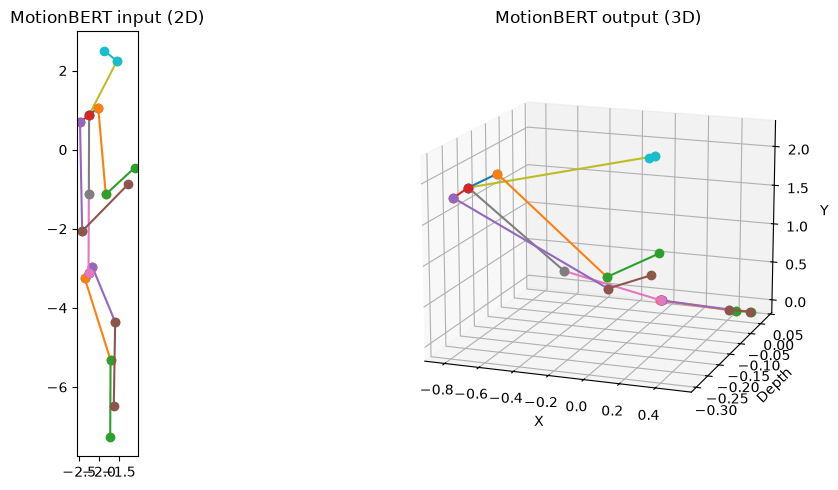

In [9]:
H36M_EDGES = [(0,1),(1,2),(2,3),(0,4),(4,5),(5,6),(0,7),(7,8),(8,9),(9,10),(8,11),(11,12),(12,13),(8,14),(14,15),(15,16)]
sample_window = 0
sample_frame = WINDOW_LENGTH // 2
pose2d = windows_input[sample_window, sample_frame, :, :2]
pose3d = poses3d_windows[sample_window, sample_frame]
fig = plt.figure(figsize=(12, 5))
axis2d = fig.add_subplot(1, 2, 1)
axis3d = fig.add_subplot(1, 2, 2, projection='3d')
for first, second in H36M_EDGES:
    axis2d.plot(pose2d[[first, second], 0], -pose2d[[first, second], 1], marker='o')
    axis3d.plot(pose3d[[first, second], 0], pose3d[[first, second], 2], -pose3d[[first, second], 1], marker='o')
axis2d.set_title('MotionBERT input (2D)')
axis2d.set_aspect('equal', adjustable='box')
axis3d.set_title('MotionBERT output (3D)')
axis3d.set_xlabel('X'); axis3d.set_ylabel('Depth'); axis3d.set_zlabel('Y')
axis3d.view_init(elev=15, azim=-70)
plt.tight_layout(); plt.show()

## 10. Sanity checks and performance record

In [10]:
bone_lengths = []
for first, second in H36M_EDGES:
    bone_lengths.append(np.linalg.norm(poses3d_windows[:, :, first] - poses3d_windows[:, :, second], axis=-1))
bone_lengths = np.stack(bone_lengths, axis=-1)
velocity = np.linalg.norm(np.diff(poses3d_windows, axis=1), axis=-1)
sanity = {
    'finite_fraction': float(np.isfinite(poses3d_windows).mean()),
    'median_bone_length_model_units': float(np.median(bone_lengths)),
    'minimum_bone_length_model_units': float(np.min(bone_lengths)),
    'median_joint_velocity_model_units_per_frame': float(np.median(velocity)),
    'maximum_joint_velocity_model_units_per_frame': float(np.max(velocity)),
}
if sanity['finite_fraction'] != 1.0 or sanity['minimum_bone_length_model_units'] <= 0:
    raise RuntimeError(f'3D sanity check failed: {sanity}')
display(pd.Series(sanity, name='value').to_frame())

,value
finite_fraction,1.000000
median_bone_length_model_units,0.380919
minimum_bone_length_model_units,0.003139
median_joint_velocity_model_units_per_frame,0.002646
maximum_joint_velocity_model_units_per_frame,0.252781


## 11. Save window-level outputs and metadata

In [11]:
WINDOW_3D_FILE = POSE3D_DIR / f'motionbert_3d_windows_{WINDOW_LENGTH}.npz'
WINDOW_3D_MANIFEST_FILE = POSE3D_DIR / f'motionbert_3d_windows_{WINDOW_LENGTH}_manifest.csv'
np.savez_compressed(
    WINDOW_3D_FILE, poses3d=poses3d_windows, inputs2d=windows_input,
    window_ids=quality_manifest['window_id'].astype(str).to_numpy(), joint_names=joint_names,
)
quality_manifest.to_csv(WINDOW_3D_MANIFEST_FILE, index=False)
metadata = {
    'created_utc': datetime.now(timezone.utc).isoformat(),
    'model': 'MotionBERT-Lite 3D pose, H36M global-lite fine-tuned checkpoint',
    'repository': REPOSITORY_URL, 'huggingface_repository': HF_REPOSITORY,
    'config': CONFIG_RELATIVE.as_posix(), 'checkpoint': CHECKPOINT_RELATIVE.as_posix(),
    'device': str(device), 'parameter_count': int(parameter_count),
    'window_length': WINDOW_LENGTH, 'windows_lifted': int(len(poses3d_windows)),
    'flip_augmentation': USE_FLIP_AUGMENTATION, 'batch_size': BATCH_SIZE,
    'mean_batch_latency_ms': float(np.mean(batch_latencies_ms)),
    'mean_latency_per_window_ms': float(sum(batch_latencies_ms) / len(poses3d_windows)),
    'limitations': [
        'MediaPipe-to-H36M mapping differs from the detector distribution used for MotionBERT training.',
        'Predicted depth is monocular and is not calibrated metric distance.',
        'The public demo clip is excluded from training and formal evaluation.',
    ],
    'sanity_checks': sanity,
}
with (RESULTS_DIR / 'motionbert_inference_metadata.json').open('w') as file:
    json.dump(metadata, file, indent=2)
print('Saved 3D windows:', WINDOW_3D_FILE.resolve())
print('Saved window manifest:', WINDOW_3D_MANIFEST_FILE.resolve())
print('Saved timeline outputs under:', POSE3D_DIR.resolve())
print('Saved metadata under:', RESULTS_DIR.resolve())

Saved 3D windows: C:\Users\manth\Desktop\project_v2\data\poses_3d\motionbert_3d_windows_81.npz
Saved window manifest: C:\Users\manth\Desktop\project_v2\data\poses_3d\motionbert_3d_windows_81_manifest.csv
Saved timeline outputs under: C:\Users\manth\Desktop\project_v2\data\poses_3d
Saved metadata under: C:\Users\manth\Desktop\project_v2\results\motionbert_3d


## Completion criteria

Notebook 03 is successful when:

- the official config and checkpoint are found;
- the input tensor is `(N, 81, 17, 3)`;
- the 3D output tensor is also `(N, 81, 17, 3)`;
- all coordinates are finite and the 3D skeleton plot is anatomically plausible;
- `data/poses_3d` contains window-level and per-video outputs; and
- latency and device metadata are saved.

### Next notebook
**Notebook 04: 3D Posture Features and Issue Rules** will compute neck, torso, lean and shoulder-asymmetry features from the 3D sequences, introduce personal calibration, and generate a continuous posture score. Formal learning/evaluation waits until participant-labelled videos exist.